In [2]:
import pandas as pd

# 读取数据
df = pd.read_csv("tiktok_dataset.csv")

# 1. 看形状：多少行 × 多少列
print("数据规模：", df.shape)

# 2. 看前5行长什么样
df.head()

数据规模： (19382, 12)


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [8]:
# 3. 看每列的类型、有没有缺失值
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  str    
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  str    
 5   verified_status           19382 non-null  str    
 6   author_ban_status         19382 non-null  str    
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
 12  like_rate                 19084 non-null  float64
 13  comment_rate              19084 non-null  float64
 14  share_rate       

In [9]:
# 删掉互动数据缺失的298行
df = df.dropna()

# 再确认一下
print("清洗后规模：", df.shape)
df.describe()


清洗后规模： (19084, 15)


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_rate,comment_rate,share_rate
count,19084.000000,1.908400e+04,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9542.500000,5.624840e+09,32.423811,254708.558688,84304.636030,16735.248323,1049.429627,349.312146,276.092725,0.954173,54.859656
std,5509.220604,2.537030e+09,16.226470,322893.280814,133420.546814,32036.174350,2004.299894,799.638865,173.006060,1.325550,50.596640
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4771.750000,3.425100e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000,130.239746,0.098234,14.445245
50%,9542.500000,5.609500e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000,264.036911,0.454819,39.738599
75%,14313.250000,7.840823e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000,398.482307,1.267995,81.864044
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000,666.647935,10.279544,265.955541


In [10]:
# 数字显示优化：不用科学计数法，保留2位小数
pd.set_option('display.float_format', '{:,.2f}'.format)

# 计数列转回整数（已经没有缺失值了，不用带 .0）
count_cols = ['video_view_count','video_like_count','video_share_count',
              'video_download_count','video_comment_count']
df[count_cols] = df[count_cols].astype(int)

df.describe()


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_rate,comment_rate,share_rate
count,"19,084.00","19,084.00","19,084.00","19,084.00","19,084.00","19,084.00","19,084.00","19,084.00","19,084.00","19,084.00","19,084.00"
mean,"9,542.50","5,624,839,917.87",32.42,"254,708.56","84,304.64","16,735.25","1,049.43",349.31,276.09,0.95,54.86
std,"5,509.22","2,537,030,180.26",16.23,"322,893.28","133,420.55","32,036.17","2,004.30",799.64,173.01,1.33,50.60
min,1.00,"1,234,959,018.00",5.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"4,771.75","3,425,100,251.25",18.00,"4,942.50",810.75,115.00,7.00,1.00,130.24,0.10,14.45
50%,"9,542.50","5,609,500,370.00",32.00,"9,954.50","3,403.50",717.00,46.00,9.00,264.04,0.45,39.74
75%,"14,313.25","7,840,823,300.50",47.00,"504,327.00","125,020.00","18,222.00","1,156.25",292.00,398.48,1.27,81.86
max,"19,084.00","9,999,873,075.00",60.00,"999,817.00","657,830.00","256,130.00","14,994.00","9,599.00",666.65,10.28,265.96


In [11]:
# 把视频按时长分成4档：0-15秒、16-30秒、31-45秒、46-60秒
bins = [0, 15, 30, 45, 60]
labels = ['0-15秒', '16-30秒', '31-45秒', '46-60秒']
df['时长区间'] = pd.cut(df['video_duration_sec'], bins=bins, labels=labels)

# 看每档有多少视频、平均播放量、中位数播放量
result = df.groupby('时长区间', observed=True)['video_view_count'].agg(['count', 'mean', 'median'])
result


,count,mean,median
时长区间,,,
0-15秒,3836,"251,213.40","9,920.00"
16-30秒,5047,"257,694.38","14,331.00"
31-45秒,5092,"249,900.02","9,968.50"
46-60秒,5109,"259,175.79","9,913.00"


In [12]:
# 认证博主真的更吃香吗？
df.groupby('verified_status', observed=True)['video_view_count'].agg(['count','mean','median'])


,count,mean,median
verified_status,,,
not verified,17884,"265,663.79","46,723.00"
verified,1200,"91,439.16","6,023.50"


In [13]:
# 什么内容类型更火？
df.groupby('claim_status', observed=True)['video_view_count'].agg(['count','mean','median'])


,count,mean,median
claim_status,,,
claim,9608,"501,029.45","501,555.00"
opinion,9476,"4,956.43","4,953.00"


In [14]:
# 计算三种互动率（每1000次播放带来多少互动）
df['like_rate'] = df['video_like_count'] / df['video_view_count'] * 1000
df['comment_rate'] = df['video_comment_count'] / df['video_view_count'] * 1000
df['share_rate'] = df['video_share_count'] / df['video_view_count'] * 1000

# 看看整体水平
df[['like_rate','comment_rate','share_rate']].describe()


,like_rate,comment_rate,share_rate
count,"19,084.00","19,084.00","19,084.00"
mean,276.09,0.95,54.86
std,173.01,1.33,50.60
min,0.00,0.00,0.00
25%,130.24,0.10,14.45
50%,264.04,0.45,39.74
75%,398.48,1.27,81.86
max,666.65,10.28,265.96


In [15]:
# 对比 claim 类和 opinion 类谁的互动率更高
df.groupby('claim_status', observed=True)[['like_rate','comment_rate','share_rate']].median()


,like_rate,comment_rate,share_rate
claim_status,,,
claim,329.73,0.77,49.67
opinion,218.13,0.25,32.49


In [16]:
# 博主状态（正常 / 被审查 / 被封）和播放量的关系
df.groupby('author_ban_status', observed=True)['video_view_count'].agg(['count','mean','median'])


,count,mean,median
author_ban_status,,,
active,15383,"215,927.04","8,616.00"
banned,1635,"445,845.44","448,201.00"
under review,2066,"392,204.84","365,245.50"


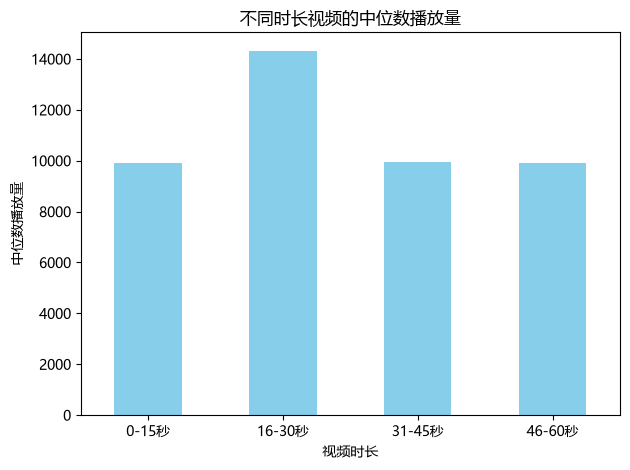

In [17]:
import matplotlib.pyplot as plt

# 设置中文显示（Windows系统）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 按时长区间统计中位数播放量
duration_stats = df.groupby('时长区间', observed=True)['video_view_count'].median()

# 画柱状图
duration_stats.plot(kind='bar', color='skyblue')
plt.title('不同时长视频的中位数播放量')
plt.xlabel('视频时长')
plt.ylabel('中位数播放量')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


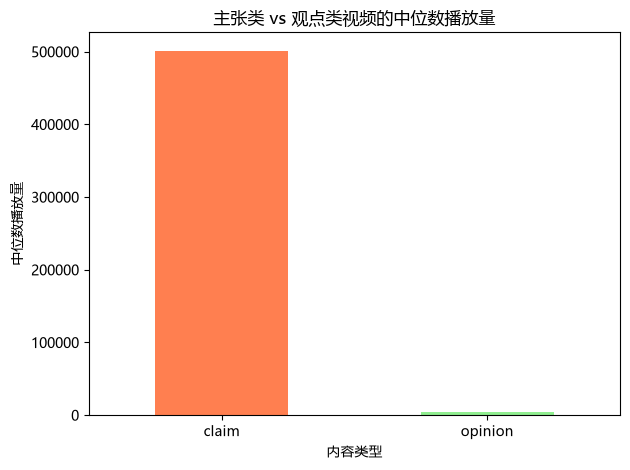

In [18]:
claim_stats = df.groupby('claim_status', observed=True)['video_view_count'].median()
claim_stats.plot(kind='bar', color=['coral', 'lightgreen'])
plt.title('主张类 vs 观点类视频的中位数播放量')
plt.xlabel('内容类型')
plt.ylabel('中位数播放量')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


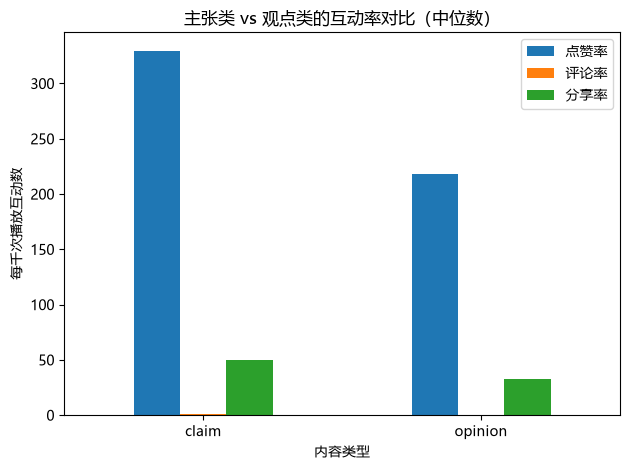

In [19]:
rate_stats = df.groupby('claim_status', observed=True)[['like_rate','comment_rate','share_rate']].median()
rate_stats.plot(kind='bar')
plt.title('主张类 vs 观点类的互动率对比（中位数）')
plt.xlabel('内容类型')
plt.ylabel('每千次播放互动数')
plt.xticks(rotation=0)
plt.legend(['点赞率','评论率','分享率'])
plt.tight_layout()
plt.show()


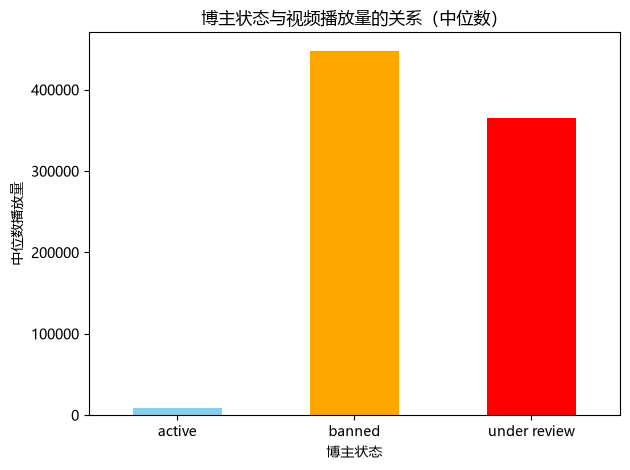

In [20]:
ban_stats = df.groupby('author_ban_status', observed=True)['video_view_count'].median()
ban_stats.plot(kind='bar', color=['skyblue', 'orange', 'red'])
plt.title('博主状态与视频播放量的关系（中位数）')
plt.xlabel('博主状态')
plt.ylabel('中位数播放量')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [21]:
# 重新创建时长区间
bins = [0, 15, 30, 45, 60]
labels = ['0-15秒', '16-30秒', '31-45秒', '46-60秒']
df['时长区间'] = pd.cut(df['video_duration_sec'], bins=bins, labels=labels)

# 不同时长区间的互动率对比
duration_rates = df.groupby('时长区间', observed=True)[['like_rate','comment_rate','share_rate']].median()
duration_rates


,like_rate,comment_rate,share_rate
时长区间,,,
0-15秒,256.03,0.46,38.89
16-30秒,266.83,0.47,39.34
31-45秒,265.23,0.44,39.58
46-60秒,265.76,0.45,40.97


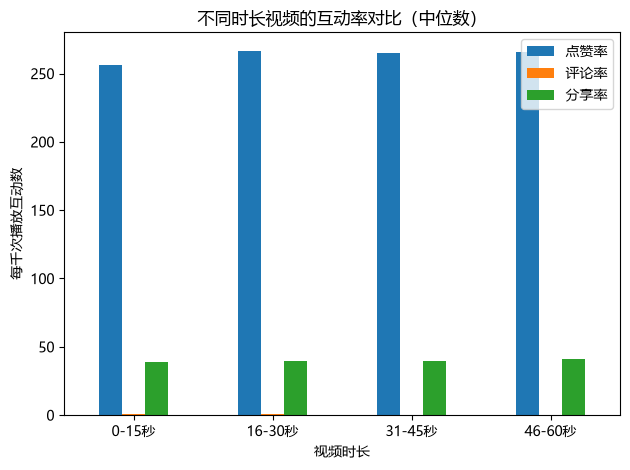

In [22]:
duration_rates.plot(kind='bar')
plt.title('不同时长视频的互动率对比（中位数）')
plt.xlabel('视频时长')
plt.ylabel('每千次播放互动数')
plt.xticks(rotation=0)
plt.legend(['点赞率','评论率','分享率'])
plt.tight_layout()
plt.show()
